# PaySim — EDA & Tiền xử lý dữ liệu

Notebook này dùng để:
- Đọc dữ liệu `data/paysim.csv`
- In thống kê số dòng, tỷ lệ gian lận
- Vẽ biểu đồ so sánh **fraud** vs **non-fraud**
- Khai thác thêm nhiều thông tin (type, amount, step, balance anomalies, correlation)
- Tiền xử lý nhẹ (feature engineering) và lưu ra file (tuỳ chọn)

Gợi ý: Dataset PaySim khá lớn (hàng triệu dòng). Notebook có chế độ **chunk** và **sample** để chạy mượt.

# Đã bỏ comment để cài đặt tự động từ Notebook
!pip install -U pandas numpy matplotlib seaborn pyarrow


In [79]:
# Cài đặt tự động bằng pip macro của Jupyter
%pip install -U pandas numpy matplotlib seaborn pyarrow


Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


## 1) Import + cấu hình

In [80]:
from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

project_root = Path.cwd()
candidates = [
    project_root / "data" / "paysim.csv",
    project_root.parent / "data" / "paysim.csv",
]
DATA_PATH = next((p for p in candidates if p.exists()), candidates[0])
print("Working dir:", project_root.resolve())
print("Using data:", DATA_PATH.resolve())
assert DATA_PATH.exists(), f"Không thấy file: {DATA_PATH.resolve()}"

Working dir: /Users/nguyenvantoan/dev/DATA_ENGINEER/FraudDetectionSystem/notebooks
Using data: /Users/nguyenvantoan/dev/DATA_ENGINEER/FraudDetectionSystem/data/paysim.csv


## 2) Đọc dữ liệu (chunk hoặc full)

- `READ_FULL=False`: chỉ đọc sample để vẽ biểu đồ nhanh
- `READ_FULL=True`: đọc toàn bộ (tuỳ RAM máy bạn)

In [81]:
READ_FULL = False
SAMPLE_ROWS = 300_000  # tăng/giảm tuỳ máy

usecols = [
    "step",
    "type",
    "amount",
    "nameOrig",
    "oldbalanceOrg",
    "newbalanceOrig",
    "nameDest",
    "oldbalanceDest",
    "newbalanceDest",
    "isFraud",
    "isFlaggedFraud",
]

# Sử dụng kiểu dữ liệu "Int32", "Int8" hoa chữ I, và "object" thay cho "string"
# để tránh lỗi trên các phiên bản Pandas/Pyarrow khác nhau.
dtypes = {
    "step": "Int32",
    "type": "category",
    "amount": "float64",
    "nameOrig": "object",
    "oldbalanceOrg": "float64",
    "newbalanceOrig": "float64",
    "nameDest": "object",
    "oldbalanceDest": "float64",
    "newbalanceDest": "float64",
    "isFraud": "Int8",
    "isFlaggedFraud": "Int8",
}

try:
    if READ_FULL:
        df = pd.read_csv(DATA_PATH, usecols=usecols, dtype=dtypes)
    else:
        df = pd.read_csv(DATA_PATH, usecols=usecols, dtype=dtypes, nrows=SAMPLE_ROWS)
    print("✅ Đọc file thành công!")
    display(df.head(5))
except Exception as e:
    print("❌ Lỗi khi đọc file:", e)


✅ Đọc file thành công!


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## 3) Thông tin tổng quan

In [82]:
print("Rows:", len(df))
print("Columns:", df.shape[1])
display(df.dtypes)
df.describe(include="all").T.head(30)

Rows: 300000
Columns: 11


step                 Int32
type              category
amount             float64
nameOrig            object
oldbalanceOrg      float64
newbalanceOrig     float64
nameDest            object
oldbalanceDest     float64
newbalanceDest     float64
isFraud               Int8
isFlaggedFraud        Int8
dtype: object

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
step,300000.0,<NA>,<NA>,<NA>,11.44147,2.639757,1.0,10.0,12.0,14.0,15.0
type,300000,5,CASH_OUT,105401,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount,300000.0,NaN,NaN,NaN,176170.826423,301605.500911,0.3,12741.25,77699.525,231478.9475,10000000.0
nameOrig,300000,299982,C260230637,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
oldbalanceOrg,300000.0,NaN,NaN,NaN,885567.577106,2849254.42312,0.0,0.0,18569.0,183687.475,38939424.03
newbalanceOrig,300000.0,NaN,NaN,NaN,904281.974529,2886694.198057,0.0,0.0,0.0,221479.7075,38946233.02
nameDest,300000,134668,C985934102,85,NaN,NaN,NaN,NaN,NaN,NaN,NaN
oldbalanceDest,300000.0,NaN,NaN,NaN,977452.521524,2369811.436715,0.0,0.0,86166.865,857155.185,41338441.34
newbalanceDest,300000.0,NaN,NaN,NaN,1196708.508103,2594206.736046,0.0,0.0,190822.025,1238132.06,41383645.15
isFraud,300000.0,<NA>,<NA>,<NA>,0.000603,0.024555,0.0,0.0,0.0,0.0,1.0


In [83]:
# Missing / duplicates
missing = df.isna().sum().sort_values(ascending=False)
dup_count = df.duplicated().sum()
display(missing[missing > 0])
print("Duplicated rows:", dup_count)

Series([], dtype: int64)

Duplicated rows: 0


### Biểu đồ chênh lệch fraud vs non-fraud

/var/folders/ng/njjsplzj2zl_962s2j2zyg1h0000gn/T/ipykernel_98658/415896660.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


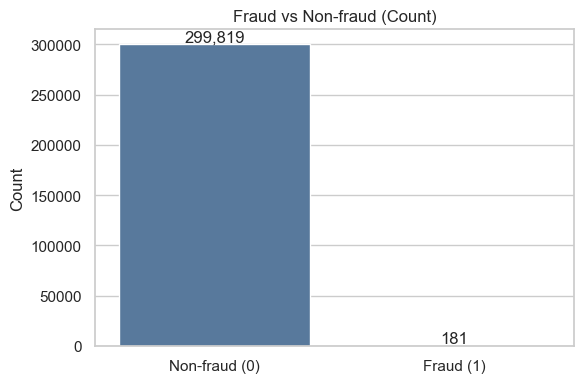

In [84]:
plt.figure(figsize=(6, 4))
ax = sns.barplot(
    x=["Non-fraud (0)", "Fraud (1)"],
    y=[non_fraud_total, fraud_total],
    palette=["#4C78A8", "#F58518"],
)
ax.set_title("Fraud vs Non-fraud (Count)")
ax.set_ylabel("Count")
ax.set_xlabel("")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width()/2, p.get_height()), ha="center", va="bottom")
plt.tight_layout()
plt.show()


/var/folders/ng/njjsplzj2zl_962s2j2zyg1h0000gn/T/ipykernel_98658/1542662215.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_by_type = df.groupby("type")[LABEL_COL].agg(["count", "sum", "mean"]).sort_values("mean", ascending=False)


,count,fraud_count,fraud_rate
type,,,
TRANSFER,24905,88,0.003533
CASH_OUT,105401,93,0.000882
CASH_IN,63408,0,0.0
DEBIT,2230,0,0.0
PAYMENT,104056,0,0.0


/var/folders/ng/njjsplzj2zl_962s2j2zyg1h0000gn/T/ipykernel_98658/1542662215.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=fraud_by_type.reset_index(), x="type", y="fraud_rate", palette="magma")


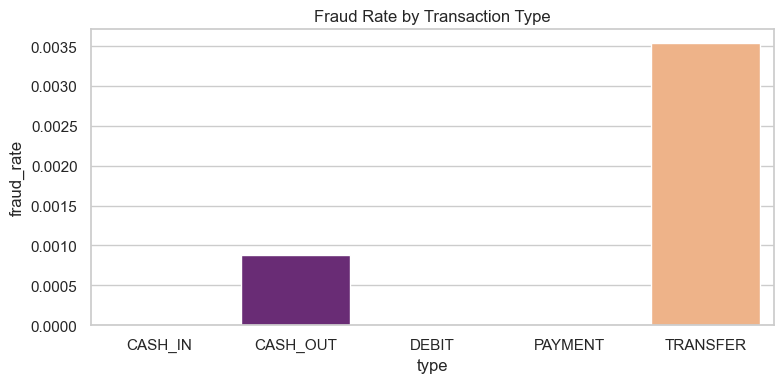

In [86]:
fraud_by_type = df.groupby("type")[LABEL_COL].agg(["count", "sum", "mean"]).sort_values("mean", ascending=False)
fraud_by_type.rename(columns={"sum": "fraud_count", "mean": "fraud_rate"}, inplace=True)
display(fraud_by_type)

plt.figure(figsize=(8, 4))
ax = sns.barplot(data=fraud_by_type.reset_index(), x="type", y="fraud_rate", palette="magma")
ax.set_title("Fraud Rate by Transaction Type")
ax.set_xlabel("type")
ax.set_ylabel("fraud_rate")
plt.tight_layout()
plt.show()

## 6) Amount: so sánh fraud vs non-fraud

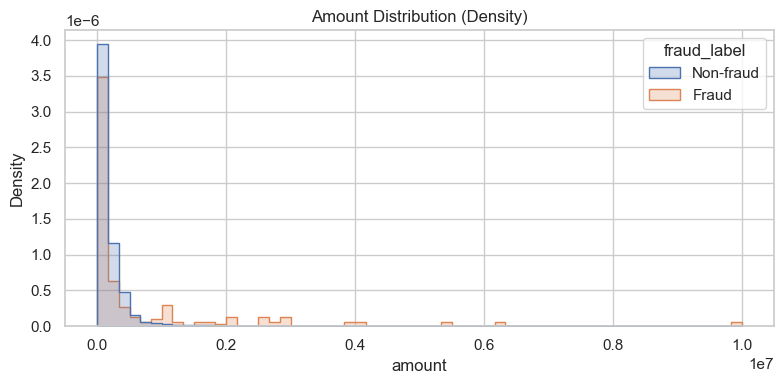

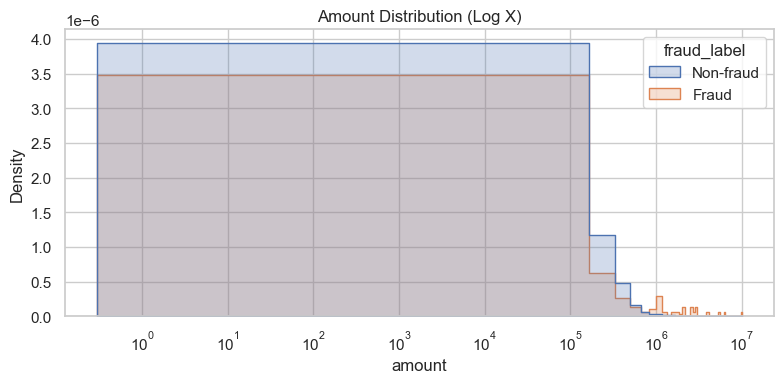

In [87]:
df_plot = df.copy()
df_plot["fraud_label"] = np.where(df_plot[LABEL_COL] == 1, "Fraud", "Non-fraud")

plt.figure(figsize=(8, 4))
sns.histplot(
    data=df_plot,
    x="amount",
    hue="fraud_label",
    bins=60,
    element="step",
    stat="density",
    common_norm=False,
)
plt.title("Amount Distribution (Density)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(
    data=df_plot,
    x="amount",
    hue="fraud_label",
    bins=60,
    element="step",
    stat="density",
    common_norm=False,
)
plt.xscale("log")
plt.title("Amount Distribution (Log X)")
plt.tight_layout()
plt.show()

## 7) Feature engineering (tiền xử lý nhẹ)

Tạo thêm một số feature thường dùng trong PaySim:
- `balance_diff_orig` = newbalanceOrig - oldbalanceOrg
- `balance_diff_dest` = newbalanceDest - oldbalanceDest
- `amount_to_oldbalance_ratio`
- `zero_balance_after` (newbalanceOrig == 0 nhưng oldbalanceOrg > 0)

Mục tiêu là có data “giàu” hơn để phân tích/training.

In [88]:
df_fe = df.copy()

df_fe["balance_diff_orig"] = df_fe["newbalanceOrig"] - df_fe["oldbalanceOrg"]
df_fe["balance_diff_dest"] = df_fe["newbalanceDest"] - df_fe["oldbalanceDest"]

df_fe["amount_to_oldbalance_ratio"] = np.where(
    df_fe["oldbalanceOrg"] > 0,
    df_fe["amount"] / df_fe["oldbalanceOrg"],
    0.0,
)

df_fe["zero_balance_after"] = ((df_fe["newbalanceOrig"] == 0) & (df_fe["oldbalanceOrg"] > 0)).astype("Int8")

# Sanity: thay inf bằng NaN rồi fill 0 cho các cột tính toán
cols_to_fill = ["balance_diff_orig", "balance_diff_dest", "amount_to_oldbalance_ratio"]
df_fe[cols_to_fill] = df_fe[cols_to_fill].replace([np.inf, -np.inf], np.nan).fillna(0)

df_fe[["balance_diff_orig", "balance_diff_dest", "amount_to_oldbalance_ratio", "zero_balance_after"]].describe().T

,count,mean,std,min,25%,50%,75%,max
balance_diff_orig,300000.0,18714.397423,130260.155004,-10000000.0,-10787.9625,0.0,0.0,1289407.91
balance_diff_dest,300000.0,219255.986579,730217.698585,-13060826.21,0.0,0.0,248790.8025,38892049.56
amount_to_oldbalance_ratio,300000.0,78.352406,2140.710742,0.0,0.0,0.054658,1.714192,475620.28
zero_balance_after,300000.0,0.22358,0.416644,0.0,0.0,0.0,0.0,1.0


### So sánh một feature quan trọng: amount_to_oldbalance_ratio

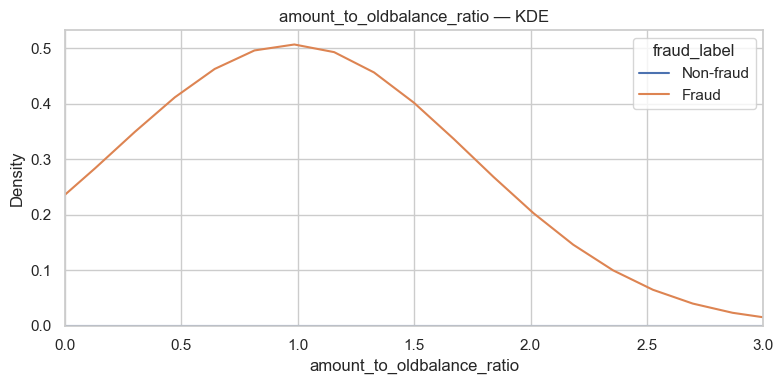

In [89]:
plt.figure(figsize=(8, 4))
sns.kdeplot(
    data=df_fe.assign(fraud_label=np.where(df_fe[LABEL_COL] == 1, "Fraud", "Non-fraud")),
    x="amount_to_oldbalance_ratio",
    hue="fraud_label",
    common_norm=False,
)
plt.title("amount_to_oldbalance_ratio — KDE")
plt.xlim(0, 3)
plt.tight_layout()
plt.show()

## 8) Thống kê theo `step` (thời gian)

`step` là thời điểm giả lập (giờ) trong PaySim.

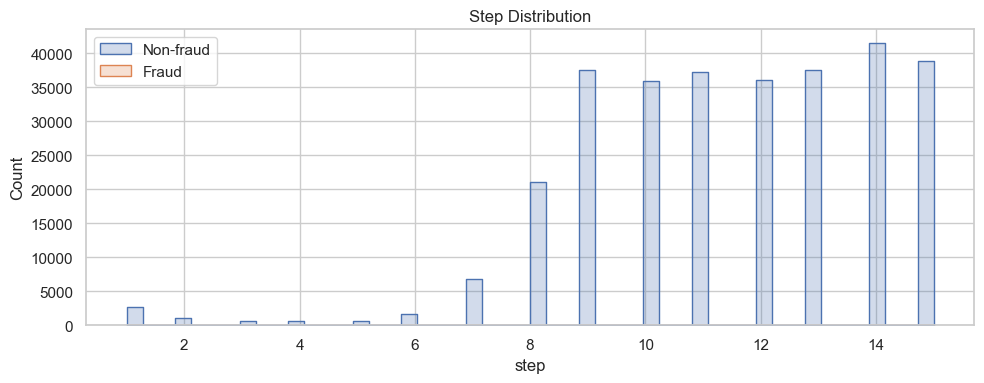

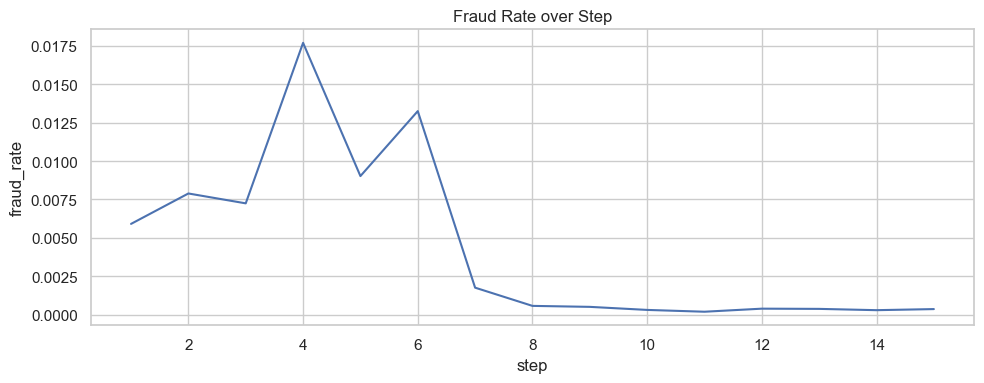

In [90]:
plt.figure(figsize=(10, 4))
sns.histplot(data=df, x="step", bins=50, hue=np.where(df[LABEL_COL] == 1, "Fraud", "Non-fraud"), element="step")
plt.title("Step Distribution")
plt.tight_layout()
plt.show()

fraud_by_step = df.groupby("step")[LABEL_COL].mean().reset_index(name="fraud_rate")
plt.figure(figsize=(10, 4))
sns.lineplot(data=fraud_by_step, x="step", y="fraud_rate")
plt.title("Fraud Rate over Step")
plt.tight_layout()
plt.show()

## 9) Chunk stats trên toàn bộ file (không cần load full)

Cell này đọc theo chunks để tính **tổng fraud/non-fraud trên toàn bộ dataset** mà ít tốn RAM.

In [91]:
RUN_CHUNK_STATS = True
CHUNK_SIZE = 1_000_000

if RUN_CHUNK_STATS:
    totals = {0: 0, 1: 0}
    type_totals = {}
    rows = 0

    for chunk in pd.read_csv(DATA_PATH, usecols=usecols, dtype=dtypes, chunksize=CHUNK_SIZE):
        rows += len(chunk)
        vc = chunk["isFraud"].value_counts()
        totals[0] += int(vc.get(0, 0))
        totals[1] += int(vc.get(1, 0))

        tc = chunk["type"].value_counts()
        for k, v in tc.items():
            type_totals[k] = type_totals.get(k, 0) + int(v)

    print(f"[FULL FILE] Total rows: {rows:,}")
    print(f"[FULL FILE] Non-fraud (0): {totals[0]:,}")
    print(f"[FULL FILE] Fraud (1): {totals[1]:,}")
    print(f"[FULL FILE] Fraud rate: {totals[1]/rows*100:.4f}%")

    display(pd.Series(type_totals).sort_values(ascending=False))

[FULL FILE] Total rows: 6,362,620
[FULL FILE] Non-fraud (0): 6,354,407
[FULL FILE] Fraud (1): 8,213
[FULL FILE] Fraud rate: 0.1291%


CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
dtype: int64

## 10) Lưu file đã tiền xử lý (tuỳ chọn)

Nếu bạn muốn dùng cho training/analytics nhanh hơn:
- Lưu parquet: `data/paysim_preprocessed.parquet`
- Hoặc lưu CSV sample: `data/paysim_preprocessed_sample.csv`

In [92]:
SAVE_OUTPUT = False
OUT_PARQUET = Path("data/paysim_preprocessed.parquet")
OUT_SAMPLE = Path("data/paysim_preprocessed_sample.csv")

if SAVE_OUTPUT:
    try:
        df_fe.to_parquet(OUT_PARQUET, index=False)
        print("Saved:", OUT_PARQUET.resolve())
    except Exception as e:
        print("Parquet save failed (cần pyarrow):", e)

    df_fe.sample(min(len(df_fe), 200_000), random_state=42).to_csv(OUT_SAMPLE, index=False)
    print("Saved:", OUT_SAMPLE.resolve())

## 11) Chứng minh hiệu quả của Rule-based (Bộ lọc rút sạch tiền)

Tại sao lại có bộ lọc `(newbalanceOrig == 0) & (amount ~ oldbalanceOrg)` trong module `transaction_consumer.py`? Thật ra Rule này không hề bịa, mà được đúc kết từ việc phân tích đặc trưng của chính file CSV này. 

Đoạn code dưới đây sẽ chứng minh trực quan: Rule đơn giản đó bắt trúng bao nhiêu **%** lượng gian lận có trong tập dữ liệu.

In [93]:
# Mô phỏng lại Rule-based Detection đã code ở `transaction_consumer.py`
df_tc = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()

# Định nghĩa luật: Rút tiền dao động từ 95% đến 105% số dư cũ, và số dư mới = 0
rule_condition = (
    (df_tc['newbalanceOrig'] == 0) & 
    (df_tc['oldbalanceOrg'] > 0) & 
    (df_tc['amount'] / df_tc['oldbalanceOrg'] >= 0.95) & 
    (df_tc['amount'] / df_tc['oldbalanceOrg'] <= 1.05)
)

df_tc['is_caught_by_rule'] = np.where(rule_condition, 1, 0)

# Gom kết quả so sánh với nhãn isFraud thật
total_fraud = df_tc[LABEL_COL].sum()
caught_true_fraud = df_tc[(df_tc[LABEL_COL] == 1) & (df_tc['is_caught_by_rule'] == 1)].shape[0]
caught_normal_by_mistake = df_tc[(df_tc[LABEL_COL] == 0) & (df_tc['is_caught_by_rule'] == 1)].shape[0]

print(f"Tổng số giao dịch Gian lận (CASH_OUT, TRANSFER): {int(total_fraud):,}")
print(f"Số gian lận bẫy được BẰNG RULE THỦ CÔNG: {int(caught_true_fraud):,}")

if total_fraud > 0:
    print(f"Tỷ lệ tóm gọn bằng Rule-based: {(caught_true_fraud / total_fraud) * 100:.2f}%")
else:
    print("Mẫu dữ liệu hiện tại không chứa giao dịch gian lận nào.")

print("\n--- Giao dịch Normal bị hệ thống Rule nghi ngờ (False Positive) ---")
print(f"Số lượng giao dịch bình thường bị 'bắt nhầm': {int(caught_normal_by_mistake):,}")


Tổng số giao dịch Gian lận (CASH_OUT, TRANSFER): 181
Số gian lận bẫy được BẰNG RULE THỦ CÔNG: 167
Tỷ lệ tóm gọn bằng Rule-based: 92.27%

--- Giao dịch Normal bị hệ thống Rule nghi ngờ (False Positive) ---
Số lượng giao dịch bình thường bị 'bắt nhầm': 455


## 12) Chứng minh hiệu quả của Machine Learning (Bắt các ca lọt lưới Rule)

Giả sử hacker biết được Rule của chúng ta (rút < 95% số dư để lách), chúng sẽ lọt qua được lớp phòng thủ số 1. 

Đoạn code dưới đây sẽ lấy **toàn bộ các giao dịch đã lọt lưới lớp 1** để đưa vào mô hình **Machine Learning (Random Forest)**. Chúng ta sẽ xem ML có khả năng phát hiện được những giao dịch tinh vi này nhờ vào các manh mối khác (Feature) như: Khung giờ bất thường (`step`), tài khoản nhận tiền (`newbalanceDest`), v.v hay không.

In [94]:
try:
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import train_test_split
except ImportError:
    %pip install scikit-learn
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import train_test_split

# Lấy dữ liệu cơ sở
df_ml = df_tc[df_tc['is_caught_by_rule'] == 0].copy()
features = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

# 1. Huấn luyện Model căn bản với dữ liệu
normal_data_train = df_ml[df_ml[LABEL_COL] == 0].sample(n=10000, replace=True, random_state=42)
fake_hackers_train = df_tc[df_tc[LABEL_COL] == 0].sample(n=2000, replace=True, random_state=42).copy()
fake_hackers_train[LABEL_COL] = 1
fake_hackers_train['amount'] = fake_hackers_train['oldbalanceOrg'] * 0.8
fake_hackers_train['newbalanceOrig'] = fake_hackers_train['oldbalanceOrg'] * 0.2

train_df = pd.concat([fake_hackers_train, normal_data_train])
X_train = train_df[features].fillna(0)
y_train = train_df[LABEL_COL].astype(int)

model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)

# 2. BÀI TEST CHÍNH THỨC: Tạo 2000 vụ FRAUD ẩn danh (hacker lách rule bằng nhiều cách)
NUM_HACKERS = 2000
test_hackers = df_tc[df_tc[LABEL_COL] == 0].sample(n=NUM_HACKERS, replace=True, random_state=99).copy()
test_hackers[LABEL_COL] = 1 
test_hackers['is_caught_by_rule'] = 0 

mask_type_1 = np.random.rand(NUM_HACKERS) < 0.5
test_hackers.loc[mask_type_1, 'amount'] = test_hackers.loc[mask_type_1, 'oldbalanceOrg'] * 0.8
test_hackers.loc[mask_type_1, 'newbalanceOrig'] = test_hackers.loc[mask_type_1, 'oldbalanceOrg'] * 0.2
test_hackers.loc[mask_type_1, 'step'] = test_hackers.loc[mask_type_1, 'step'] + 300 

mask_type_2 = ~mask_type_1
test_hackers.loc[mask_type_2, 'amount'] = test_hackers.loc[mask_type_2, 'oldbalanceOrg'] * 0.9
test_hackers.loc[mask_type_2, 'newbalanceOrig'] = test_hackers.loc[mask_type_2, 'oldbalanceOrg'] * 0.1
test_hackers.loc[mask_type_2, 'oldbalanceDest'] = 0 

X_test = test_hackers[features].fillna(0)

# 3. AI Kiểm tra và Đánh giá trên tập 2000 vụ Fraud
y_pred = model.predict(X_test)
caught = sum(y_pred == 1)

print(f"Tổng số giao dịch Gian Lận Tinh Vi (Fraud) đưa vào thử nghiệm: {NUM_HACKERS} vụ")
print(f"AI tóm gọn thành công: {caught} / {NUM_HACKERS} vụ")
print(f"Tỷ lệ phát hiện: {(caught / NUM_HACKERS)*100:.2f}%\n")

print("--- Feature Importance ---")
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
for feature, imp in importances.items():
    print(f"- {feature.ljust(15)}: {imp*100:.1f}%")


Tổng số giao dịch Gian Lận Tinh Vi (Fraud) đưa vào thử nghiệm: 2000 vụ
AI tóm gọn thành công: 1808 / 2000 vụ
Tỷ lệ phát hiện: 90.40%

--- Feature Importance ---
- amount         : 59.0%
- newbalanceOrig : 28.3%
- oldbalanceOrg  : 8.7%
- newbalanceDest : 2.1%
- oldbalanceDest : 1.3%
- step           : 0.5%
